In [85]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# read csv
df = pd.read_csv("../players.csv")

In [86]:
# get age from date of birth
df["date_of_birth"] = pd.to_datetime(df["date_of_birth"], errors="coerce")
dob = df["date_of_birth"]
today = pd.Timestamp.today().normalize()
df["age"] = (
    today.year
    - dob.dt.year
    - ((today.month < dob.dt.month) |
    ((today.month == dob.dt.month) & (today.day < dob.dt.day)))
)

# take only the columns that matter
df = df[["age", "height_in_cm", "position", "market_value_in_eur"]].dropna()

# ensure what we have is numeric
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["height_in_cm"] = pd.to_numeric(df["height_in_cm"], errors="coerce")
df["market_value_in_eur"] = pd.to_numeric(df["market_value_in_eur"], errors="coerce")

# data cleanup - position "Missing" is present in dataset, so - remove it.
df = df.dropna()
df = df[df["position"] != "Missing"]

# everything that we have is numeric, except position.
# so - one hot it and create X amount of position_NAME for our dataframe
# but also drop attacker to avoid colinearity! if all positions in row are 0, then player is attacker...
df = pd.get_dummies(df, columns=["position"], dtype=np.float64, drop_first=True)

# log1p value to reduce skew
df["log_value"] = np.log1p(df["market_value_in_eur"])

In [87]:
# standardize numeric columns, because very different scales at work here
feature_df = df.drop(columns=["market_value_in_eur", "log_value"])
num_cols = ["age", "height_in_cm"]
mu = feature_df[num_cols].mean()
sigma = feature_df[num_cols].std().replace(0, 1)

# z score of numeric columns
feature_df[num_cols] = (feature_df[num_cols] - mu) / sigma

In [88]:
# fit our model using gradient descent...
def linear_regression(X, y, lr=0.01, epochs=30000):
    m, n = X.shape
    w = np.zeros(n, dtype=np.float64)
    b = 0.0

    for _ in range(epochs):
        y_pred = X @ w + b
        error = y_pred - y

        # chain rule to find the PDs for weight and bias...
        dw = (2.0 / m) * (X.T @ error)
        db = (2.0 / m) * float(np.sum(error))

        # apply learning rate to weights and bias
        w -= lr * dw
        b -= lr * db

    return w, b

In [89]:
# three feature sets:
# age
# age, height
# age, height, position

# our LHS
y = df["log_value"].to_numpy(dtype=np.float64)

models = []
models_scikit = []
y_pred = []
y_pred_scikit = []

X_train, X_test, y_train, y_test = train_test_split(
    feature_df,
    y,
    test_size=0.2
)

# our RHS for just age
Xtr = X_train[["age"]].to_numpy(dtype=np.float64)
Xte = X_test[["age"]].to_numpy(dtype=np.float64)
w, b = linear_regression(Xtr, y_train)
models.append((w, b))
y_pred.append((Xte @ w + b))

sk = LinearRegression()
sk.fit(Xtr, y_train)
models_scikit.append((sk.coef_, float(sk.intercept_)))
y_pred_scikit.append((sk.predict(Xte)))

# our RHS for age, height
Xtr = X_train[["age", "height_in_cm"]].to_numpy(dtype=np.float64)
Xte = X_test[["age", "height_in_cm"]].to_numpy(dtype=np.float64)
w, b = linear_regression(Xtr, y_train)
models.append((w, b))
y_pred.append((Xte @ w + b))

sk = LinearRegression()
sk.fit(Xtr, y_train)
models_scikit.append((sk.coef_, float(sk.intercept_)))
y_pred_scikit.append((sk.predict(Xte)))

# full RHS
Xtr = X_train.to_numpy(dtype=np.float64)
Xte = X_test.to_numpy(dtype=np.float64)
w, b = linear_regression(Xtr, y_train)
models.append((w, b))
y_pred.append((Xte @ w + b))

sk = LinearRegression()
sk.fit(Xtr, y_train)
models_scikit.append((sk.coef_, float(sk.intercept_)))
y_pred_scikit.append((sk.predict(Xte)))

print(models)
print(models_scikit)

[(array([-0.42139893]), 12.715449126516415), (array([-0.4214994 , -0.00851355]), 12.715472261131735), (array([-0.41267619,  0.0830167 , -0.08785619, -0.71377122, -0.01457246]), 12.826843406220037)]
[(array([-0.42139893]), 12.715449126516459), (array([-0.4214994 , -0.00851355]), 12.715472261131778), (array([-0.41267619,  0.0830167 , -0.08785619, -0.71377122, -0.01457246]), 12.826843406220565)]


1.1532547879816324 1.5004584522992213 0.07788127156448388
1.1532547879816357 1.500458452299221 0.07788127156448421
---------------
1.1533040873547262 1.500449813062684 0.07789189015757314
1.1533040873547293 1.5004498130626835 0.0778918901575737
---------------
1.1413271997285472 1.4829066201629273 0.09932833082375225
1.141327199728551 1.4829066201629209 0.09932833082376014
---------------


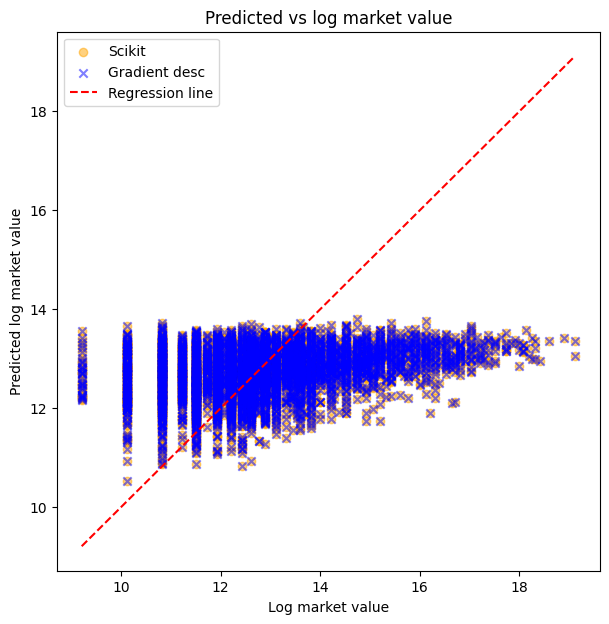

In [97]:
def metrics(y, y_hat):
    mae = mean_absolute_error(y, y_hat)
    rmse = np.sqrt(mean_squared_error(y, y_hat))
    r2 = r2_score(y, y_hat)
    return mae, rmse, r2

for i in range(3):
    mae, rmse, r2 = metrics(y_test, y_pred[i])
    mae_scikit, rmse_scikit, r2_scikit = metrics(y_test, y_pred_scikit[i])
    print(mae, rmse, r2)
    print(mae_scikit, rmse_scikit, r2_scikit)
    print("---------------")
    

plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred_scikit[2],
            color="orange",
            alpha=0.5,
            marker="o",
            label="Scikit")

plt.scatter(y_test, y_pred[2],
            color="blue",
            alpha=0.5,
            marker="x",
            label="Gradient desc")

plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
    color="red",
    linestyle="--",
    label="Regression line"
)
plt.xlabel("Log market value")
plt.ylabel("Predicted log market value")
plt.title("Predicted vs log market value")

plt.legend()
plt.show()

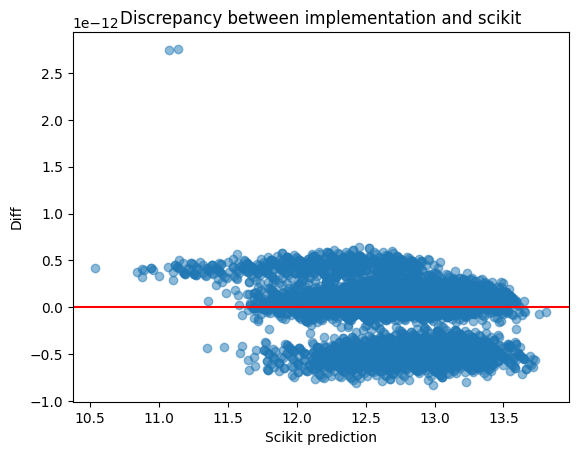

In [100]:
diff = y_pred[2] - y_pred_scikit[2]
plt.scatter(y_pred_scikit[2], diff, alpha=0.5)
plt.axhline(0, color="red")

plt.xlabel("Scikit prediction")
plt.ylabel("Diff")
plt.title("Discrepancy between implementation and scikit")

plt.show()

# Interpretation and conclusion

1. Player age by itself explains only a small part of the difference in market value between players, thus age only has a limited impact on a player's valuation.
2. Adding height to our model did not improve predictive performance, thus height does not meaningfully influence a player's valuation in football.
3. Adding positional information improved the model slightly, meaning market value based on what position a player is in does tend to affect their market value.
4. Even our best model - which included age, height, and the player's positional information - was able to capture an R2 score of about 10%, meaning using these three variables only explained about 10% of the variance in player valuation. This highlights that our feature set is rather limited and information which would heavily describe a player's valuation are not available in our feature set (or our dataset, even).
5. Our implementation and the one provided by Scikit produced nearly identical results, achieving a near-zero discrepancy. Our custom gradient descent converges to the same least-squares solutions as the ones in Scikit's linear regression model, thus our implementation of linear regression is correct.